# <u>Lab Two - Classification</u>

Authors:  Muskaan Mahes, Chloe Prowse, Aayush Dalal, Nino Castellano

In [1]:
# Necessary imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## 1) <u> Data Preparation </u>

### Define and Prepare Class Variables

The Student Placement Dataset from Kaggle was collected and analyzed to determine whether students’ results were sufficient to obtain a job offer. The dataset contained over 50,000 records consisting of academic, technical, and soft-skill attributes that can influence the outcome of being placed or not. <b>(This is our primary Classification Task #1)</b> Therefore, the primary purpose of the dataset is to help students, educational institutions, career centers understand which factors are crucial for achieving a successful placement outcome. 

We previously used this data to analyze and explore the relationships between students’ key features and their placement outcome to identify important insights. We then built and evaluated two classification models (SVM and Logistic Regression) to predict a student's placement status based on various academic, technical, and personal attributes. Now our objective is to take it a step further by training and evaluating different classification models for our existing classification task, Placement Status, while also training/evaluating those same models on a different classification task we can come up with from this data.

For example, as a <b>Secondary Classification Task #2 </b> aligned with our broader goal of understanding the factors that contribute to long-term career success, we could classify a student’s likelihood of securing an internship based on their current academic, technical, and personal attributes. Predicting internship attainment is particularly meaningful because internships often serve as a critical stepping stone toward full-time employment. By modeling internship probability, we can evaluate where a student currently stands in their professional development journey and identify areas for improvement. Since even a single internship can significantly increase the likelihood of receiving a full-time offer later, this secondary task provides both practical and predictive value alongside our primary placement classification objective.

Summarizing Clasification Tasks:

- <b>Placement Outcome (Yes or No) </b>
- <b>Internship Placement (Yes or No) </b>

Together, these two classification tasks create a developmental pathway: predicting internship probability drives short-term skill adjustments that increase immediate opportunities, and those strengthened skills directly feed into improved placement outcomes, ultimately supporting long-term full-time career success.

In [2]:
#loading dataset
df = pd.read_csv("full_dataset.csv")
print(df.shape)
df.head()

(50000, 15)


,Student_ID,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status
0,1048,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed
1,37820,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed
2,49668,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed
3,19467,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed
4,23094,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed


### Describe Final Dataset

Using our previously preprocessed from earlier labs which has already been cleaned, and verified to contain no missing values; the data is ready preprocessing using encoding and scaling and then for model training and testing. The only additional step required is to create a new encoded target variable, <b>Internship Placement</b>, derived from the <b>Internships</b> feature. Students with at least one internship will be labeled <b>Yes</b>, while those with none will be labeled <b>No</b>.

In [3]:
#dropping ID Because it is not useful for the model
df = df.drop(columns=["Student_ID"], errors='ignore')

# Create Internship Placement binary target variable
df["Internship_Placement"] = np.where(df["Internships"] >= 1, "Yes", "No")

#identifying numeric and categorical columns
numeric_columns = df.select_dtypes(include=[np.number]).columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Verify the identified columns
print("Numeric Columns:", len(numeric_columns))
print(numeric_columns)
print("Categorical Columns:", len(categorical_columns))
print(categorical_columns)

Numeric Columns: 10
Index(['Age', 'CGPA', 'Internships', 'Projects', 'Coding_Skills',
       'Communication_Skills', 'Aptitude_Test_Score', 'Soft_Skills_Rating',
       'Certifications', 'Backlogs'],
      dtype='object')
Categorical Columns: 5
Index(['Gender', 'Degree', 'Branch', 'Placement_Status',
       'Internship_Placement'],
      dtype='object')


In [4]:
print(df.shape)
df.head()

(50000, 15)


,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status,Internship_Placement
0,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,Not Placed,No
1,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,Not Placed,Yes
2,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,Not Placed,Yes
3,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,Placed,Yes
4,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,Placed,Yes


## 2) <u> Modeling and Evaluation </u>

### Choosing and Explaining Evaluation Metrics

*Nino's Task: To Ellaborate more on Why we are using Precision for Evaluation*

### Method for Splitting Train and Test Sets

*Nino's Task: Explain the Splitting Criteria and Stratefied Fold*

In [5]:
# Encoding Placement_Status (Task 1)
le_task1 = LabelEncoder()
df["Placement_Status"] = le_task1.fit_transform(df["Placement_Status"])

# Encoding Internship_Placement (Task 2)
le_task2 = LabelEncoder()
df["Internship_Placement"] = le_task2.fit_transform(df["Internship_Placement"])

In [6]:
df.head()

,Age,Gender,Degree,Branch,CGPA,Internships,Projects,Coding_Skills,Communication_Skills,Aptitude_Test_Score,Soft_Skills_Rating,Certifications,Backlogs,Placement_Status,Internship_Placement
0,22,Female,B.Tech,ECE,6.29,0,3,4,6,51,5,1,3,0,0
1,20,Female,BCA,ECE,6.05,1,4,6,8,59,8,2,1,0,1
2,22,Male,MCA,ME,7.22,1,4,6,6,58,6,2,2,0,1
3,22,Male,MCA,ME,7.78,2,4,6,6,90,4,2,0,1,1
4,20,Female,B.Tech,ME,7.63,1,4,6,5,79,6,2,0,1,1


In [7]:
# Getting Test and Train Split for Task 1: Placement Status Classification
X_task1 = df.drop(columns=["Placement_Status", "Internship_Placement"])
y_task1 = df["Placement_Status"]

# Identify feature types AFTER dropping targets
numeric_columns_task1 = X_task1.select_dtypes(include=np.number).columns
categorical_columns_task1 = X_task1.select_dtypes(include="object").columns

# Preprocessor for Task 1
preprocessor_task1 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns_task1),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns_task1)
    ]
)

# Train Test Split
X_train_task1, X_test_task1, y_train_task1, y_test_task1 = train_test_split(
    X_task1,
    y_task1,
    test_size=0.3,
    random_state=42,
    stratify=y_task1
)

# Fit ONLY on train
X_train_task1 = preprocessor_task1.fit_transform(X_train_task1)
X_test_task1 = preprocessor_task1.transform(X_test_task1)

In [8]:
# Getting Test and Train Data for Task 2: Internship Placement Classification
X_task2 = df.drop(columns=[
    "Internship_Placement", # target variable for Task 2
    "Internships",          # used to create target
    "Placement_Status"      # logically happens after internship
])

y_task2 = df["Internship_Placement"]

X_train_task2, X_test_task2, y_train_task2, y_test_task2 = train_test_split(
    X_task2, y_task2,
    test_size=0.3,
    random_state=42,
    stratify=y_task2
)

# IMPORTANT:
# Recreate column lists for Task 2 (since we dropped features)

numeric_columns_task2 = X_task2.select_dtypes(include=np.number).columns
categorical_columns_task2 = X_task2.select_dtypes(include="object").columns

preprocessor_task2 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns_task2),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_columns_task2)
    ]
)

X_train_task2 = preprocessor_task2.fit_transform(X_train_task2)
X_test_task2 = preprocessor_task2.transform(X_test_task2)

In [9]:
# Final Ready-to-Use Data
print("TASK 1 Ready Shapes:")
print(X_train_task1.shape, X_test_task1.shape)

print("\nTASK 2 Ready Shapes:")
print(X_train_task2.shape, X_test_task2.shape)

TASK 1 Ready Shapes:
(35000, 18) (15000, 18)

TASK 2 Ready Shapes:
(35000, 17) (15000, 17)


<u>Note on how to Plug and Play Test and Train Sets into Models</u>

Task 1 Train and Test Sets (Placement Status):
X_train_task1, X_test_task1, y_train_task1, y_test_task1

Task 2 Train and Test Sets (Internship Placement):
X_train_task2, X_test_task2, y_train_task2, y_test_task2

Instructions on How to Use:

1. Initialize model
2. Fit on train
3. Predict on test
4. Evaluate

Example Classifier for Task 1:

Initialize

- rf = RandomForestClassifier(random_state=42)

Train

- rf.fit(X_train_task1, y_train_task1)

Predict on test set

- y_pred_task1 = rf.predict(X_test_task1)

Evaluate

- print("Accuracy:", accuracy_score(y_test_task1, y_pred_task1))
- print(classification_report(y_test_task1, y_pred_task1))



### Three Different Classification/Regression Models

SVM Classifier

In [16]:
from sklearn.model_selection import train_test_split

# TASK 1: Placement_Status
y_task1 = df["Placement_Status"]

X_task1 = df.drop(["Placement_Status", "Internship_Placement"], axis=1)

X_task1 = pd.get_dummies(X_task1, drop_first=True)

X_train_task1, X_test_task1, y_train_task1, y_test_task1 = train_test_split(
    X_task1,
    y_task1,
    test_size=0.2,
    random_state=42,
    stratify=y_task1
)

# TASK 2: Internship_Placement
y_task2 = df["Internship_Placement"]

X_task2 = df.drop(["Internship_Placement", "Placement_Status", "Internships"], axis=1)

X_task2 = pd.get_dummies(X_task2, drop_first=True)

X_train_task2, X_test_task2, y_train_task2, y_test_task2 = train_test_split(
    X_task2,
    y_task2,
    test_size=0.2,
    random_state=42,
    stratify=y_task2
)

In [17]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize SVM
svm_task1 = SVC(kernel='rbf', C=1, gamma='scale')

# Train
svm_task1.fit(X_train_task1, y_train_task1)

# Predict
y_pred_task1 = svm_task1.predict(X_test_task1)

# Evaluate
print("Accuracy:", accuracy_score(y_test_task1, y_pred_task1))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_task1, y_pred_task1))
print("\nClassification Report:\n", classification_report(y_test_task1, y_pred_task1))

# TASK 2: Internship_Placement SVM

# Initialize SVM
svm_task2 = SVC(kernel='rbf', C=1, gamma='scale')

# Train
svm_task2.fit(X_train_task2, y_train_task2)

# Predict
y_pred_task2 = svm_task2.predict(X_test_task2)

# Evaluate
print("Accuracy:", accuracy_score(y_test_task2, y_pred_task2))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_task2, y_pred_task2))
print("\nClassification Report:\n", classification_report(y_test_task2, y_pred_task2))

Accuracy: 0.8744

Confusion Matrix:
 [[5793  582]
 [ 674 2951]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.91      0.90      6375
           1       0.84      0.81      0.82      3625

    accuracy                           0.87     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.87      0.87     10000

Accuracy: 0.7033

Confusion Matrix:
 [[3148 1443]
 [1524 3885]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.69      0.68      4591
           1       0.73      0.72      0.72      5409

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



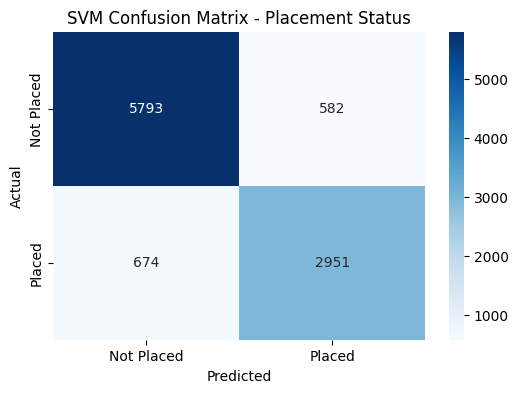

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_task1, y_pred_task1)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Placed","Placed"],
            yticklabels=["Not Placed","Placed"])
plt.title("SVM Confusion Matrix - Placement Status")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The SVM model performs well for predicting Placement_Status, achieving an accuracy of 87.44%. The model correctly classified 5793 students as Not Placed and 2951 as Placed. Some errors occurred, including 582 false positives and 674 false negatives, but most predictions fall along the diagonal of the confusion matrix, indicating strong overall performance.

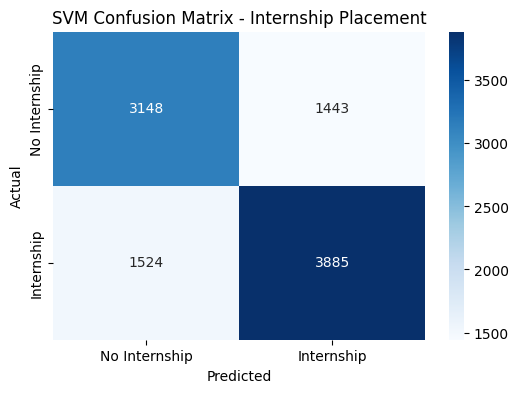

In [20]:
cm = confusion_matrix(y_test_task2, y_pred_task2)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Internship","Internship"],
            yticklabels=["No Internship","Internship"])
plt.title("SVM Confusion Matrix - Internship Placement")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The SVM model achieved 70.33% accuracy when predicting Internship_Placement. It correctly classified 3148 students with no internship and 3885 students with internships. However, there were 1443 false positives and 1524 false negatives, indicating that predicting internship placement is more difficult with the available features.

### Analyze Model Results Using Choosen Evaluation Metric

The Support Vector Machine (SVM) classifier was evaluated using accuracy, precision, recall, and F1-score. These metrics provide a comprehensive view of model performance by measuring both overall accuracy and class-level prediction quality.

For the Placement_Status task, the model achieved an accuracy of 87.44%, indicating strong predictive performance. The confusion matrix shows that most predictions were correct, with 5793 students correctly classified as Not Placed and 2951 correctly classified as Placed. Precision and recall scores also indicate that the model performs well for both classes, although predictions for the Placed category are slightly less accurate.

Overall, the SVM model demonstrates strong performance and generalizes well when predicting student placement outcomes.

### Discuss Advantages of Each Model on Each Classification/Regression Task

One advantage of Support Vector Machines is their ability to handle datasets with many features. In this dataset, attributes such as CGPA, internships, projects, coding skills, and aptitude scores all contribute to predicting placement outcomes. SVM works well in these situations because it finds an optimal decision boundary that separates the classes.

Another advantage is the ability to capture nonlinear relationships using kernel functions. The Radial Basis Function (RBF) kernel allows the model to identify complex relationships between student attributes and placement outcomes that may not be linearly separable.

Overall, SVM provides a reliable classification model that balances strong predictive accuracy with good generalization.

### Which Attributes are Most Important for each Classification Task

Although SVM models do not directly provide feature importance scores, important attributes can be inferred based on their relationship to the target variables.

For predicting Placement_Status, features related to academic performance and technical ability are likely the most influential. These include CGPA, coding skills, number of projects, aptitude test scores, and certifications, which reflect a student’s qualifications and readiness for employment.

Additionally, communication skills and soft skills ratings may also play an important role, since employers often evaluate both technical knowledge and interpersonal abilities during hiring decisions.

Overall, attributes related to academic performance, technical skills, and professional experience appear to be the most important factors in predicting placement outcomes.

## 3) <u> Deployment </u>

### Usefulness of Model to Interested Parties 

## 4) <u> Exceptional Work </u>

### Additional Model or Hyperparameter Tuning Via Grid Search